# Action 인디게임 초기 리뷰 기반 유저 기대·불만 요인 분석

## 0. 프로젝트 주제와 이번 분석의 위치

본 노트북은 `01_llm_sentiment_Action_v1.ipynb`에서 생성된 LLM 분석 결과 CSV를 바탕으로,  
**Action 장르 인디게임 유저들이 출시 초기 리뷰에서 어떤 요소를 긍정적으로 평가하고, 어떤 요소를 불편하게 느꼈는지** 정리하는 보고서


- 마크다운 셀: 결과 해석과 인사이트 설명
- 코드 셀: 보고서에 넣을 표와 그래프 출력

## 1. 프로젝트 목표와 이번 분석의 위치


본 프로젝트의 주제는 **Steam 인디게임 반응 분석을 통한 개발 의사결정 지원**이다.

프로젝트는 크게 두 관점으로 나뉜다.

| 관점 | 목적 |
| --- | --- |
| 출시 전 관점 | 장르, 태그, 플레이 방식, 가격대 등 게임 속성과 초기 반응 지표를 비교해 출시 전략에 참고할 수 있는 근거를 만든다. |
| 출시 후 관점 | 특정 게임의 리뷰 수, 긍정률, 리뷰 본문을 바탕으로 유저 반응의 원인을 해석하고, 부정 리뷰의 반복 이슈를 유형화해 패치 및 운영 우선순위를 제안한다. |

이번 LLM 리뷰 감성분석은 **출시 전 관점**에 해당한다.

즉, 특정 게임 1개의 패치 우선순위를 정하는 분석이 아닌  
**Action 장르 인디게임의 출시 초기 리뷰를 분석하여 해당 장르 유저들이 무엇을 좋아하고 무엇을 불편해하는지 파악하는 분석**이다.

따라서 본 분석 결과는 Action 장르 게임을 개발하거나 출시 준비 중인 인디 개발자가 출시 전 단계에서 어떤 요소를 우선 점검해야 하는지 판단하는 참고 근거로 활용한다.

> 추후엔 Action 외의 다양한 장르를 시도할 예정

In [11]:
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown


# ============================================================
# 1. 파일 경로 설정
# ============================================================

ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")
RUN_NAME = "main_action_d0_d30"

OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME

RESULT_PATH = OUTPUT_DIR / "steam_review_llm_results.csv"
TAG_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"
ISSUE_PRIORITY_PATH = OUTPUT_DIR / "llm_issue_priority_summary.csv"

# ============================================================
# 2. 데이터 불러오기
# ============================================================
df_result = pd.read_csv(RESULT_PATH)
df_tags = pd.read_csv(TAG_PATH)
df_issue = pd.read_csv(ISSUE_PRIORITY_PATH)

# ============================================================
# 3. 그래프 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)



# ============================================================
# 4. 이슈명 한글 변환
# ============================================================
ISSUE_KR_MAP = dict(zip(df_issue["tag_category"], df_issue["issue_name_kor"]))

# 혹시 요약 파일에 없는 태그가 있을 경우를 대비한 보완 매핑
ISSUE_KR_MAP.update({
    "gameplay_loop": "게임플레이 루프",
    "ui_ux": "UI/UX",
    "difficulty": "난이도",
    "control": "조작감",
    "content_volume": "콘텐츠 분량",
    "bug": "버그",
    "graphics_audio": "그래픽/사운드",
    "story": "스토리",
    "multiplayer_network": "멀티/네트워크",
    "price_value": "가격/가치",
    "balance": "밸런스",
    "performance": "성능",
    "optimization": "최적화",
    "translation_localization": "번역/현지화",
    "developer_communication": "개발사 소통",
    "monetization": "과금",
    "progression_grind": "성장/반복노가다",
    "save_progression": "저장/진행",
    "crash": "크래시",
    "positive_praise": "긍정 칭찬",
    "other": "기타",
})

df_tags["issue_name"] = df_tags["tag_category"].map(ISSUE_KR_MAP).fillna(df_tags["tag_category"])
df_issue["issue_name"] = df_issue["tag_category"].map(ISSUE_KR_MAP).fillna(df_issue["tag_category"])

print("데이터 로드 완료")
print("분석 리뷰 수:", len(df_result))
print("분석 게임 수:", df_result["appid"].nunique())

데이터 로드 완료
분석 리뷰 수: 142
분석 게임 수: 17


## 2. 분석 대상 및 기준

이번 분석은 Action 계열 인디게임 표본의 출시 초기 리뷰를 대상으로 한다.  
리뷰는 출시 후 초기 구간인 `D0-D7`, `D8-D30`에 작성된 리뷰를 중심으로 분석하였다.

아래 표는 이번 LLM 분석의 기본 범위와 조건이다.

| 항목 | 내용 |
| --- | --- |
| 분석 대상 장르 | Action 계열 stratum |
| 출시일 기준 | 2024-01-01 이후 |
| 리뷰 언어 | English |
| 리뷰 구간 | D0-D7, D8-D30 |
| 리뷰 조건 | Steam 구매 리뷰, 무료 수령 리뷰 제외, 얼리액세스 리뷰 제외 |
| 게임당 샘플 수 | 최대 12개 |
| 샘플링 방식 | Steam 긍정/부정 라벨 균형 샘플링 |
| 최종 분석 리뷰 수 | 142개 |
| 최종 분석 게임 수 | 17개 |

## 3. 전체 감성 분석 결과

Steam의 추천/비추천 라벨은 유저가 최종적으로 게임을 추천했는지를 보여준다.  
반면 LLM 감성분석은 리뷰 본문을 읽고 긍정, 부정, 혼합, 중립 감정을 다시 분류한다.

이 차이를 보면, **Steam에서 긍정으로 표시된 리뷰 안에도 개선 요구가 포함될 수 있는지** 확인할 수 있다.


,항목,값
0,분석 리뷰 수,142개
1,분석 게임 수,17개
2,Steam 긍정 리뷰 비율,75.4%
3,LLM 긍정 리뷰 비율,60.6%
4,LLM 부정+혼합 리뷰 비율,37.3%
5,고위험 리뷰 비율,25.4%
6,Steam 라벨-LLM 감정 완전 일치 비율,81.7%


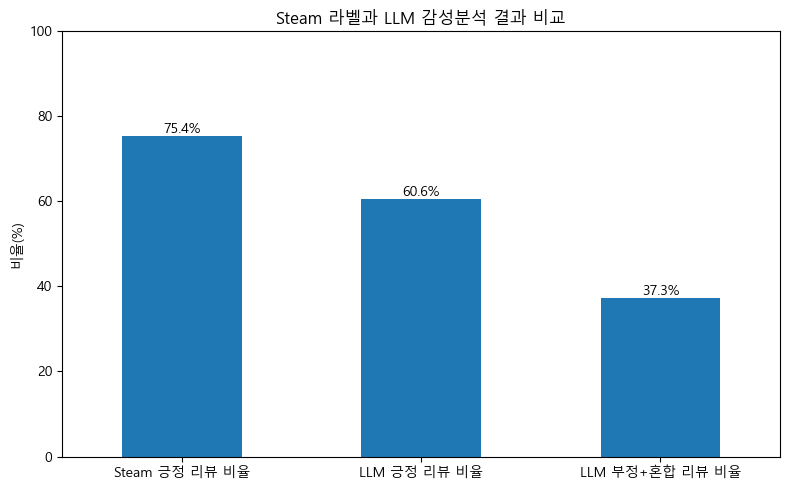

In [12]:
# ============================================================
# 전체 요약 지표 계산
# ============================================================

total_reviews = len(df_result)
total_games = df_result["appid"].nunique()

steam_positive_rate = (df_result["steam_label_text"] == "positive").mean() * 100
llm_positive_rate = (df_result["llm_sentiment"] == "positive").mean() * 100
llm_negative_mixed_rate = df_result["llm_sentiment"].isin(["negative", "mixed"]).mean() * 100
high_urgency_rate = (df_result["urgency"] == "high").mean() * 100
exact_match_rate = (df_result["sentiment_relation"] == "exact_match").mean() * 100

overall_summary = pd.DataFrame({
    "항목": [
        "분석 리뷰 수",
        "분석 게임 수",
        "Steam 긍정 리뷰 비율",
        "LLM 긍정 리뷰 비율",
        "LLM 부정+혼합 리뷰 비율",
        "고위험 리뷰 비율",
        "Steam 라벨-LLM 감정 완전 일치 비율",
    ],
    "값": [
        f"{total_reviews:,}개",
        f"{total_games:,}개",
        f"{steam_positive_rate:.1f}%",
        f"{llm_positive_rate:.1f}%",
        f"{llm_negative_mixed_rate:.1f}%",
        f"{high_urgency_rate:.1f}%",
        f"{exact_match_rate:.1f}%",
    ]
})

display(overall_summary)

# ============================================================
# 그래프 1. Steam 긍정률과 LLM 긍정률 비교
# ============================================================

rate_plot_df = pd.DataFrame({
    "지표": ["Steam 긍정 리뷰 비율", "LLM 긍정 리뷰 비율", "LLM 부정+혼합 리뷰 비율"],
    "비율": [steam_positive_rate, llm_positive_rate, llm_negative_mixed_rate],
})

ax = rate_plot_df.plot(
    x="지표",
    y="비율",
    kind="bar",
    legend=False,
    figsize=(8, 5),
    rot=0,
)

ax.set_title("Steam 라벨과 LLM 감성분석 결과 비교")
ax.set_xlabel("")
ax.set_ylabel("비율(%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### 결과 해석

Steam 기준 긍정 리뷰 비율보다 LLM 기준 긍정 리뷰 비율이 낮게 나타났다.  
이는 유저가 게임을 추천하더라도 리뷰 본문에는 조작감, 콘텐츠 분량, UI/UX 등 개선 요구가 함께 포함될 수 있음을 의미한다.

따라서 Action 장르 게임을 출시하기 전에는 단순히 유사 게임의 긍정률만 보는 것이 아니라,  
**긍정 리뷰 안에 숨어 있는 아쉬운 점까지 함께 확인하는 방식**이 필요하다.

,감정,리뷰 수,비율
0,긍정,86,60.6
1,혼합,23,16.2
2,부정,30,21.1
3,중립,3,2.1


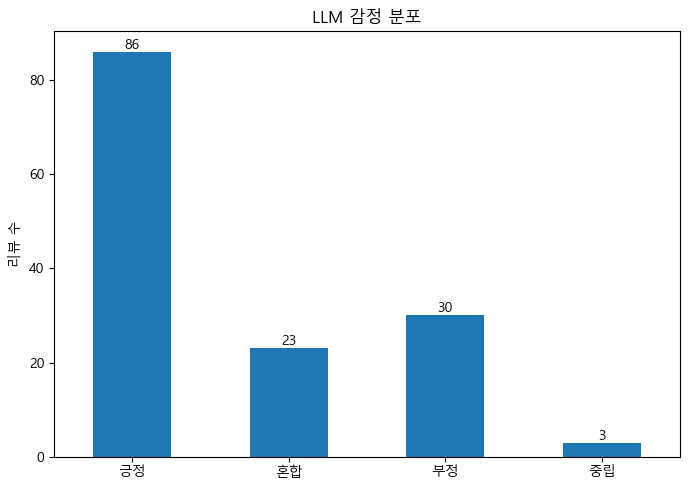

In [13]:
# ============================================================
# 그래프 2. LLM 감정 분포
# ============================================================

sentiment_order = ["positive", "mixed", "negative", "neutral"]
sentiment_name_map = {
    "positive": "긍정",
    "mixed": "혼합",
    "negative": "부정",
    "neutral": "중립",
}

sentiment_counts = (
    df_result["llm_sentiment"]
    .value_counts()
    .reindex(sentiment_order)
    .dropna()
    .astype(int)
    .reset_index()
)

sentiment_counts.columns = ["llm_sentiment", "리뷰 수"]
sentiment_counts["감정"] = sentiment_counts["llm_sentiment"].map(sentiment_name_map)
sentiment_counts["비율"] = sentiment_counts["리뷰 수"] / sentiment_counts["리뷰 수"].sum() * 100

display(sentiment_counts[["감정", "리뷰 수", "비율"]].assign(비율=lambda x: x["비율"].round(1)))

ax = sentiment_counts.plot(
    x="감정",
    y="리뷰 수",
    kind="bar",
    legend=False,
    figsize=(7, 5),
    rot=0,
)

ax.set_title("LLM 감정 분포")
ax.set_xlabel("")
ax.set_ylabel("리뷰 수")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## 4. Action 장르 유저가 긍정적으로 평가한 요소

다음 표와 그래프는 LLM이 리뷰 본문에서 긍정적으로 분류한 이슈 태그를 집계한 결과다.

여기서 중요한 점은 단순한 "좋았다" 표현보다,  
유저가 구체적으로 어떤 요소를 좋게 평가했는지를 보는 것이다.

| 긍정 요소       |   긍정 언급 수 |   언급된 게임 수 |
|:----------------|---------------:|-----------------:|
| 게임플레이 루프 |             66 |               14 |
| 그래픽/사운드   |             51 |               13 |
| 스토리          |             14 |                4 |
| 멀티/네트워크   |             11 |                5 |
| UI/UX           |              8 |                6 |
| 콘텐츠 분량     |              7 |                5 |
| 난이도          |              7 |                5 |
| 조작감          |              6 |                4 |

,긍정 요소,긍정_언급_수
12,긍정 칭찬,102
5,게임플레이 루프,66
6,그래픽/사운드,51
16,스토리,14
8,멀티/네트워크,11
17,UI/UX,8
10,기타,8
1,콘텐츠 분량,7
4,난이도,7
13,가격/가치,6


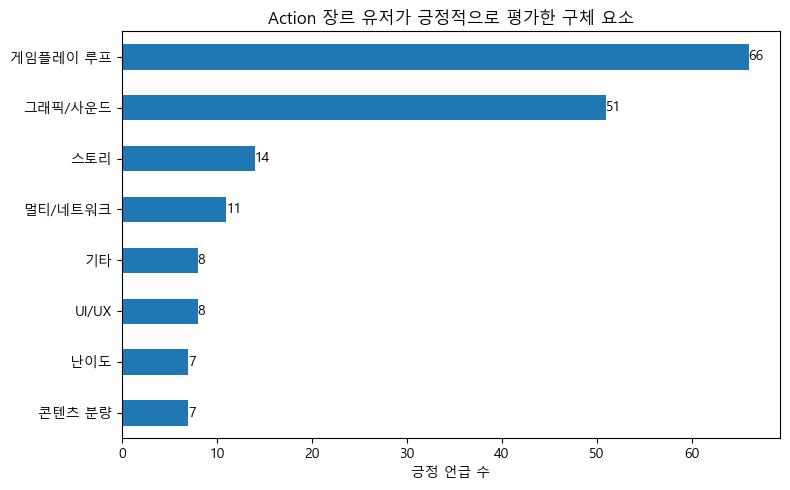

In [14]:
# ============================================================
# 긍정 태그 집계
# ============================================================

positive_tag = df_tags[df_tags["tag_sentiment"] == "positive"].copy()

positive_summary = (
    positive_tag
    .groupby(["tag_category", "issue_name"], as_index=False)
    .agg(긍정_언급_수=("tag_category", "size"))
    .sort_values("긍정_언급_수", ascending=False)
)

display(positive_summary.rename(columns={"issue_name": "긍정 요소"}).head(10)[["긍정 요소", "긍정_언급_수"]])

# ============================================================
# 그래프 3. 구체 긍정 요소 Top 8
# positive_praise는 너무 포괄적인 칭찬 표현이므로 그래프에서는 제외합니다.
# ============================================================

positive_concrete = positive_summary[positive_summary["tag_category"] != "positive_praise"].head(8)

ax = positive_concrete.sort_values("긍정_언급_수").plot(
    x="issue_name",
    y="긍정_언급_수",
    kind="barh",
    legend=False,
    figsize=(8, 5),
)

ax.set_title("Action 장르 유저가 긍정적으로 평가한 구체 요소")
ax.set_xlabel("긍정 언급 수")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 결과 해석

Action 장르 표본에서는 **게임플레이 루프, 그래픽/사운드, 스토리, 멀티/네트워크 요소**가 긍정적으로 자주 언급되었다.

특히 게임플레이 루프는 긍정 언급이 많다는 점에서,  
Action 장르 유저가 전투, 이동, 반복 플레이 구조, 조작의 손맛 같은 핵심 경험을 중요하게 평가한다고 볼 수 있다.

따라서 Action 인디게임 개발자는 출시 전 단계에서  
**짧은 플레이 시간 안에 핵심 재미가 충분히 전달되는지**를 우선 점검할 필요가 있다.

## 5. Action 장르 유저가 불편하게 느낀 요소

다음 표와 그래프는 LLM이 리뷰 본문에서 부정적으로 분류한 이슈 태그를 집계한 결과다.

이 결과는 Action 장르 게임을 출시하기 전,  
부정 리뷰로 이어질 가능성이 높은 리스크 항목을 사전에 점검하는 데 활용할 수 있다.

,불편 요소,부정_언급_수
7,게임플레이 루프,41
15,UI/UX,20
6,난이도,16
3,조작감,10
2,콘텐츠 분량,9
1,버그,7
10,기타,7
0,밸런스,6
8,그래픽/사운드,6
12,가격/가치,5


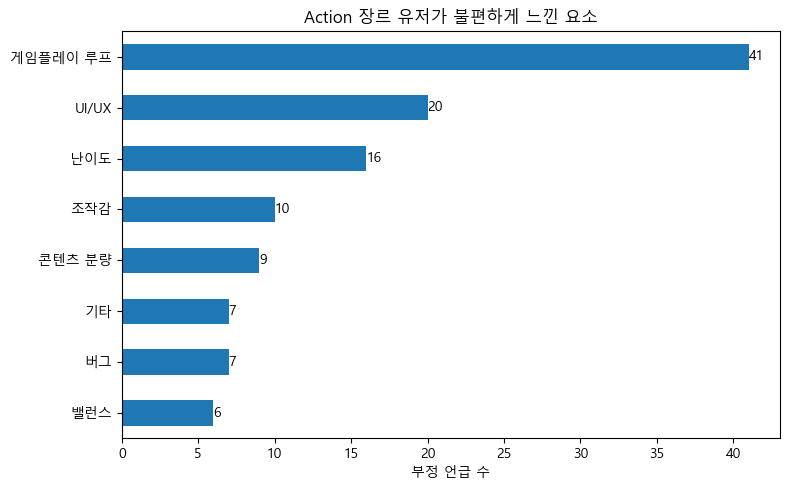

In [15]:
# ============================================================
# 부정 태그 집계
# ============================================================

negative_tag = df_tags[df_tags["tag_sentiment"] == "negative"].copy()

negative_summary = (
    negative_tag
    .groupby(["tag_category", "issue_name"], as_index=False)
    .agg(부정_언급_수=("tag_category", "size"))
    .sort_values("부정_언급_수", ascending=False)
)

display(negative_summary.rename(columns={"issue_name": "불편 요소"}).head(10)[["불편 요소", "부정_언급_수"]])

# ============================================================
# 그래프 4. 부정 요소 Top 8
# ============================================================

negative_top = negative_summary.head(8)

ax = negative_top.sort_values("부정_언급_수").plot(
    x="issue_name",
    y="부정_언급_수",
    kind="barh",
    legend=False,
    figsize=(8, 5),
)

ax.set_title("Action 장르 유저가 불편하게 느낀 요소")
ax.set_xlabel("부정 언급 수")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 결과 해석

부정 언급은 **게임플레이 루프, UI/UX, 난이도, 조작감, 콘텐츠 분량**에서 많이 나타났다.

이는 Action 장르 유저가 단순히 게임의 콘셉트만 보는 것이 아니라,  
실제 플레이 과정에서 반복 구조가 재미있는지, 조작이 자연스러운지, 난이도 적응이 가능한지, 안내가 충분한지를 중요하게 본다는 의미다.

출시 전에는 다음 항목을 우선 점검해야 한다.

- 핵심 전투/이동/반복 플레이가 지루하지 않은가
- 튜토리얼과 진행 안내가 충분한가
- 조작 옵션과 입력 피드백이 명확한가
- 초반 난이도 곡선이 급격하지 않은가
- 첫 30일 안에 콘텐츠 부족으로 느껴질 부분은 없는가

## 6. 출시 초기 구간별 유저 반응 변화

일부 요소는 긍정과 부정 양쪽에서 모두 많이 언급된다.  
이런 요소는 단순한 장점/단점이라기보다, **장르 유저가 가장 민감하게 평가하는 핵심 축**으로 보는 것이 적절하다.


,이슈,전체 언급 수,긍정 언급 수,부정 언급 수,긍정_비율,부정_비율
0,게임플레이 루프,114,66,41,57.9,36.0
18,긍정 칭찬,102,102,0,100.0,0.0
8,그래픽/사운드,59,51,6,86.4,10.2
1,UI/UX,28,8,20,28.6,71.4
2,난이도,27,7,16,25.9,59.3
4,콘텐츠 분량,22,7,9,31.8,40.9
6,기타,18,8,7,44.4,38.9
3,조작감,17,6,10,35.3,58.8
12,멀티/네트워크,15,11,2,73.3,13.3
20,스토리,15,14,0,93.3,0.0


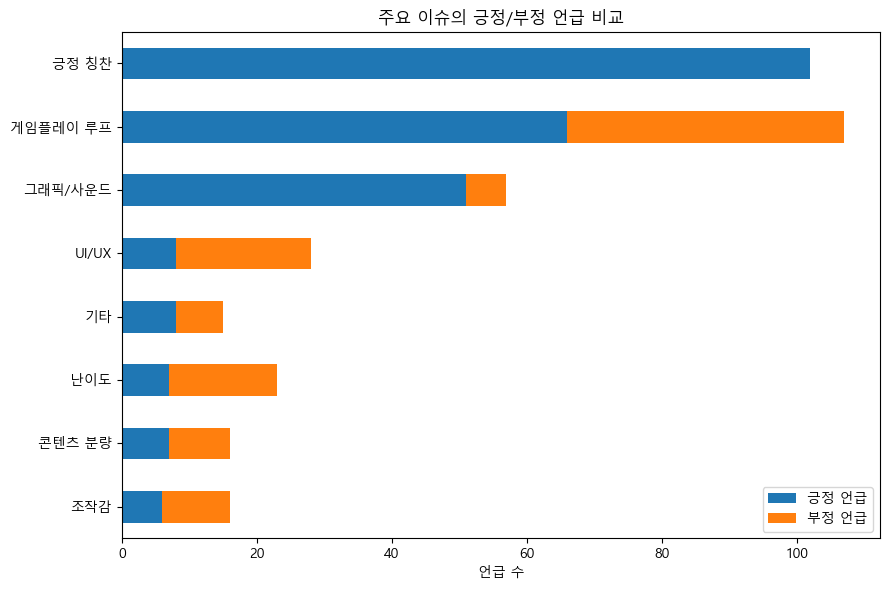

In [16]:
# ============================================================
# 긍정/부정 방향성 요약
# ============================================================

issue_direction = df_issue.copy()

issue_direction_table = (
    issue_direction
    .assign(
        부정_비율=lambda x: (x["negative_rate"] * 100).round(1),
        긍정_비율=lambda x: (x["positive_rate"] * 100).round(1),
    )
    .sort_values("total_count", ascending=False)
    .head(10)
    [["issue_name", "total_count", "positive_count", "negative_count", "긍정_비율", "부정_비율"]]
    .rename(columns={
        "issue_name": "이슈",
        "total_count": "전체 언급 수",
        "positive_count": "긍정 언급 수",
        "negative_count": "부정 언급 수",
    })
)

display(issue_direction_table)

# ============================================================
# 그래프 5. 주요 이슈의 긍정/부정 언급 비교
# ============================================================

issue_plot = (
    issue_direction
    .sort_values("total_count", ascending=False)
    .head(8)
    .set_index("issue_name")[["positive_count", "negative_count"]]
    .rename(columns={"positive_count": "긍정 언급", "negative_count": "부정 언급"})
)

ax = issue_plot.sort_values(["긍정 언급", "부정 언급"]).plot(
    kind="barh",
    stacked=True,
    figsize=(9, 6),
)

ax.set_title("주요 이슈의 긍정/부정 언급 비교")
ax.set_xlabel("언급 수")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 결과 해석

게임플레이 루프는 긍정과 부정 양쪽에서 모두 많이 언급되었다.  
따라서 게임플레이 루프는 단순한 약점이 아니라, Action 장르에서 유저 평가를 좌우하는 가장 중요한 축으로 해석할 수 있다.

반면 UI/UX, 난이도, 조작감은 부정 비율이 높게 나타났다.  
이 요소들은 게임의 아이디어가 좋더라도 출시 초기 부정 리뷰로 이어질 가능성이 높은 리스크 항목이다.

## 7. 출시 초기 구간별 반응 변화

출시 초기 리뷰는 작성 시점에 따라 성격이 조금 다를 수 있다.

- `D0-D7`: 출시 직후 첫인상, 조작, UI, 초반 재미에 대한 반응
- `D8-D30`: 어느 정도 플레이한 뒤 반복성, 콘텐츠 밀도, 난이도, 버그에 대한 반응

따라서 출시 전 점검도 첫 플레이 테스트와 일정 시간 이상 플레이 테스트를 나누어 설계하는 것이 좋다.

,release_period,리뷰_수,고위험_리뷰_수,LLM_긍정_리뷰_수,고위험_리뷰_비율,LLM_긍정_비율
0,D0-D7,101,23,61,22.8,60.4
1,D8-D30,41,13,25,31.7,61.0


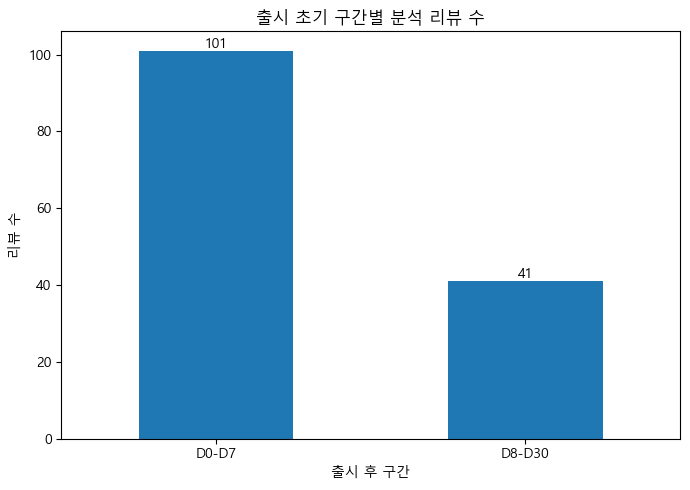

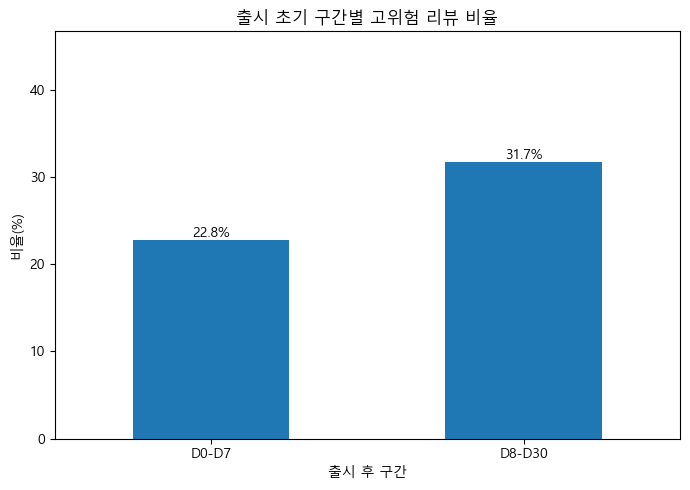

In [17]:
# ============================================================
# 출시 구간별 리뷰 수와 고위험 리뷰 비율
# ============================================================

period_summary = (
    df_result
    .groupby("release_period", as_index=False)
    .agg(
        리뷰_수=("recommendationid", "count"),
        고위험_리뷰_수=("urgency", lambda x: (x == "high").sum()),
        LLM_긍정_리뷰_수=("llm_sentiment", lambda x: (x == "positive").sum()),
    )
)

period_summary["고위험_리뷰_비율"] = (period_summary["고위험_리뷰_수"] / period_summary["리뷰_수"] * 100).round(1)
period_summary["LLM_긍정_비율"] = (period_summary["LLM_긍정_리뷰_수"] / period_summary["리뷰_수"] * 100).round(1)

display(period_summary)

# ============================================================
# 그래프 6. 출시 구간별 리뷰 수
# ============================================================

ax = period_summary.plot(
    x="release_period",
    y="리뷰_수",
    kind="bar",
    legend=False,
    figsize=(7, 5),
    rot=0,
)

ax.set_title("출시 초기 구간별 분석 리뷰 수")
ax.set_xlabel("출시 후 구간")
ax.set_ylabel("리뷰 수")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# ============================================================
# 그래프 7. 출시 구간별 고위험 리뷰 비율
# ============================================================

ax = period_summary.plot(
    x="release_period",
    y="고위험_리뷰_비율",
    kind="bar",
    legend=False,
    figsize=(7, 5),
    rot=0,
)

ax.set_title("출시 초기 구간별 고위험 리뷰 비율")
ax.set_xlabel("출시 후 구간")
ax.set_ylabel("비율(%)")
ax.set_ylim(0, max(period_summary["고위험_리뷰_비율"]) + 15)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

release_period,D0-D7,D8-D30
issue_name,,
게임플레이 루프,27.0,14.0
UI/UX,11.0,9.0
난이도,7.0,9.0
조작감,6.0,4.0
콘텐츠 분량,6.0,3.0
버그,3.0,4.0
기타,4.0,3.0
그래픽/사운드,4.0,2.0


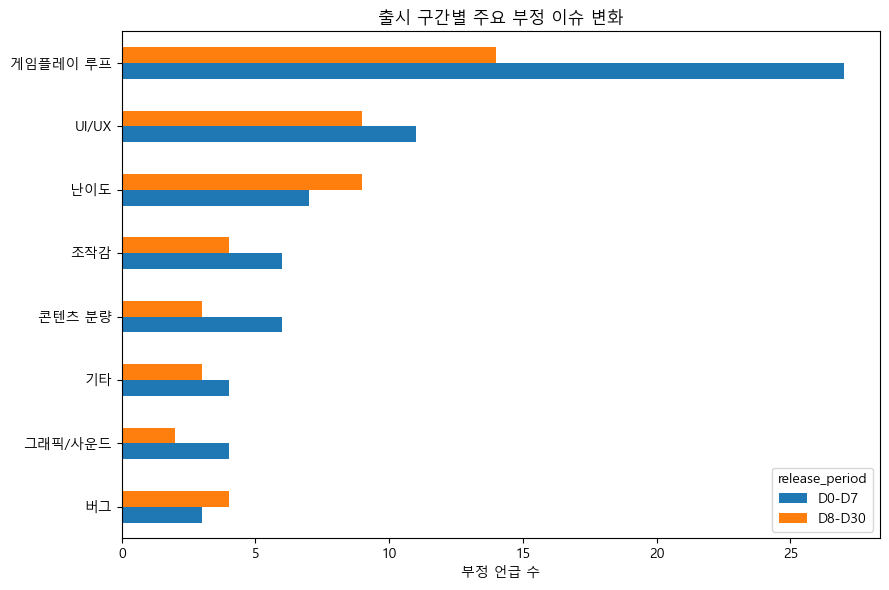

In [18]:
# ============================================================
# 출시 구간별 부정 이슈 변화
# ============================================================

period_negative_issue = (
    negative_tag
    .groupby(["release_period", "issue_name"], as_index=False)
    .agg(부정_언급_수=("tag_category", "size"))
)

period_negative_pivot = (
    period_negative_issue
    .pivot_table(
        index="issue_name",
        columns="release_period",
        values="부정_언급_수",
        fill_value=0,
    )
)

# 전체 부정 언급 수 기준 상위 8개만 표시
period_negative_pivot["전체"] = period_negative_pivot.sum(axis=1)
period_negative_top = (
    period_negative_pivot
    .sort_values("전체", ascending=False)
    .drop(columns="전체")
    .head(8)
)

display(period_negative_top)

ax = period_negative_top.sort_values(list(period_negative_top.columns)).plot(
    kind="barh",
    figsize=(9, 6),
)

ax.set_title("출시 구간별 주요 부정 이슈 변화")
ax.set_xlabel("부정 언급 수")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 결과 해석

D0-D7 구간에서는 출시 직후 첫인상과 관련된 반응이 많이 나타난다.  
따라서 이 구간에서 반복되는 UI/UX, 조작감, 초반 재미 문제는 출시 전 QA와 튜토리얼 점검에서 우선 확인해야 한다.

D8-D30 구간에서는 리뷰 수는 줄어들지만, 고위험 리뷰 비율이 더 높게 나타났다.  
이는 일정 시간 이상 플레이한 유저가 반복성, 난이도, 버그, 콘텐츠 밀도 문제를 더 강하게 인식할 수 있음을 의미한다.

따라서 출시 전 테스트는 단순 첫 플레이 확인으로 끝내기보다,  
**첫 1주일에 드러날 진입 장벽**과 **첫 1개월 안에 드러날 반복 플레이 문제**를 나누어 점검해야 한다.

## 8. 출시 전 점검 항목 도출

앞선 결과를 바탕으로 Action 장르 인디게임을 출시하기 전 점검해야 할 항목을 정리하면 다음과 같다.

이 표는 특정 게임의 패치 처방이 아니라,  
**Action 장르 유저 반응을 바탕으로 만든 출시 전 체크리스트**에 가깝다.


| 점검 영역     | 리뷰에서 확인된 의미                                | 출시 전 확인 질문                                 |
| --------- | ------------------------------------------ | ------------------------------------------ |
| 핵심 플레이 루프 | 긍정과 부정 양쪽에서 모두 많이 언급되는 핵심 평가 축             | 짧은 플레이 시간 안에 전투, 이동, 반복 플레이의 재미가 전달되는가?    |
| UI/UX     | 부정 비율이 높아 초반 진입 장벽으로 이어질 수 있는 요소           | 튜토리얼, 목표 안내, 메뉴, 피드백이 명확한가?                |
| 조작감       | 액션 장르에서 전투·이동의 손맛을 좌우하는 요소                 | 키 설정, 입력 반응, 이동/전투 조작이 자연스러운가?             |
| 난이도       | 초반 적응 실패 또는 불공정하다는 인식으로 부정 리뷰를 유발할 수 있는 요소 | 초반 난이도 곡선이 급격하거나 불공정하게 느껴지지 않는가?           |
| 콘텐츠 밀도    | 일정 시간 플레이 후 반복성·부족함으로 인식될 수 있는 요소          | 첫 30일 안에 콘텐츠가 빈약하거나 반복적이라고 느껴질 구간은 없는가?    |
| 버그/안정성    | 언급 수는 상대적으로 적어도 발생 시 강한 부정 반응으로 이어지는 요소    | 진행 불가, 크래시, 저장 문제처럼 즉시 부정 리뷰로 이어질 문제가 없는가? |
| 그래픽/사운드   | 긍정 반응에서 자주 등장하는 장르 매력 강화 요소                | 장르 분위기, 타격감, 몰입감을 강화하는 시청각 요소가 충분한가?       |


## 9. 핵심 인사이트

### 인사이트 1. Action 장르 유저는 핵심 플레이 루프를 가장 중요하게 평가한다

게임플레이 루프는 긍정과 부정 양쪽에서 모두 많이 언급되었다.  
이는 Action 장르에서 전투, 이동, 반복 플레이 구조, 조작의 손맛이 유저 평가의 중심이라는 것을 의미한다.

따라서 Action 인디게임 개발자는 출시 전 단계에서  
핵심 플레이가 짧은 시간 안에 충분히 전달되는지 점검해야 한다.

### 인사이트 2. UI/UX, 조작감, 난이도는 출시 초기 부정 반응의 주요 리스크다

UI/UX, 조작감, 난이도는 부정 언급이 많이 나타난 요소다.  
게임의 콘셉트가 좋아도 초반 조작 안내가 부족하거나 난이도 적응이 어렵다면 부정 리뷰로 이어질 수 있다.

따라서 출시 전에는 튜토리얼, 키 설정, 옵션, 난이도 곡선, 피드백 UI를 우선 점검해야 한다.

### 인사이트 3. 긍정 리뷰 안에도 개선 요구가 포함될 수 있다

Steam에서는 긍정으로 표시된 리뷰라도 LLM 기준으로는 혼합 감정으로 분류되는 경우가 존재했다.  
이는 유저가 게임을 추천하면서도 동시에 불편한 점을 남길 수 있다는 뜻이다.

따라서 유사 장르 게임을 벤치마킹할 때는 긍정률만 볼 것이 아니라,  
긍정 리뷰 안에 반복적으로 등장하는 아쉬운 점까지 확인해야 한다.

### 인사이트 4. 출시 전 점검은 D0-D7 문제와 D8-D30 문제를 나누어 설계해야 한다

D0-D7은 첫인상, 조작, UI/UX, 초반 재미와 관련이 깊고,  
D8-D30은 반복성, 콘텐츠 분량, 난이도, 버그 문제가 더 중요해질 수 있다.

따라서 출시 전 QA와 테스트는 단순 첫 플레이 테스트뿐 아니라,  
일정 시간 이상 플레이했을 때의 반복 피로도와 콘텐츠 밀도까지 함께 확인해야 한다.

## 10. 결론 및 후속 분석 방향

이번 LLM 리뷰 감성분석 결과, Action 장르 인디게임의 출시 초기 리뷰에서는 **게임플레이 루프, 그래픽/사운드, 스토리, 멀티/네트워크**가 주요 긍정 요소로 나타났다.

반대로 부정 반응에서는 **게임플레이 루프, UI/UX, 난이도, 조작감, 콘텐츠 분량, 버그, 밸런스**가 반복적으로 확인되었다.

이 결과는 Action 장르 게임을 개발하는 인디 개발사가 출시 전 단계에서 다음 요소를 우선 점검해야 함을 보여준다.

- 핵심 플레이 루프가 초반에 충분히 전달되는가
- 조작과 UI/UX가 진입 장벽이 되지 않는가
- 난이도 곡선이 초반 이탈을 유발하지 않는가
- 콘텐츠 밀도와 반복 플레이 피로도가 적절한가
- 버그와 밸런스 문제가 부정 리뷰로 이어질 가능성은 없는가

따라서 본 분석은 **출시 전 관점의 장르 유저 기대·불만 요인 분석**으로 정리하는 것이 가장 적절하다.

출시 후 관점의 분석은 별도로 진행해야 한다.  
출시 후 분석에서는 특정 게임 1개를 대상으로 리뷰 수 추이, 긍정률 변화, 부정 리뷰 원인, 긴급도, 플레이타임, 반복 불만을 종합하여 실제 패치 및 운영 우선순위를 제안하는 방식이 더 타당하다.

---

## 부록. 사용 데이터 파일

이 노트북은 아래 파일을 사용한다.

| 파일명 | 역할 |
|---|---|
| `steam_review_llm_results.csv` | LLM 리뷰 감성분석 결과 원본 |
| `llm_issue_tags_flat.csv` | 리뷰별 issue_tags를 태그 단위로 펼친 결과 |
| `llm_game_summary.csv` | 게임 단위 요약 결과 |
| `llm_issue_priority_summary.csv` | 이슈별 긍정/부정 방향성 요약 |